## Luis Fernando Jose Ruiz Ortega - 202211513


# Solución: SARSA — State-Action-Reward-State-Action

Este notebook implementa el algoritmo SARSA (on-policy TD control) y lo aplica al ambiente Cliff-Walk.

La clase `SARSA` está definida en `sarsa_agent.py` (Task 1) y se importa aquí para usarla con el ambiente Cliff-Walk (Task 2).


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

from sarsa_agent import SARSA

random.seed(42)
np.random.seed(42)

In [2]:
class CliffWalk:
    """
    Ambiente Cliff-Walk basado en Gridworld.
    Grilla 5x12. El agente comienza en (4,0) y debe llegar a (4,11)
    sin caer al barranco [(4,1) a (4,10)].
    """
    ROWS = 5
    COLS = 12
    actions = [0, 1, 2, 3]
    ACTION_NAMES = ['UP', 'DOWN', 'LEFT', 'RIGHT']
    DELTAS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
    START = (4, 0)
    GOAL  = (4, 11)
    CLIFF = {(4, c) for c in range(1, 11)}

    def __init__(self):
        self.state = self.START

    def reset(self):
        self.state = self.START
        return self.state

    def step(self, action):
        dr, dc = self.DELTAS[action]
        r, c = self.state
        new_r = max(0, min(self.ROWS - 1, r + dr))
        new_c = max(0, min(self.COLS - 1, c + dc))
        next_state = (new_r, new_c)
        if next_state in self.CLIFF:
            self.state = self.START
            return self.START, -100, False
        if next_state == self.GOAL:
            self.state = next_state
            return next_state, -1, True
        self.state = next_state
        return next_state, -1, False

    def run_episode(self, agent):
        """
        Loop SARSA
        """
        state = self.reset()
        action = agent.choose_action(state)  
        total_reward = 0
        done = False
        while not done:
            next_state, reward, done = self.step(action)          
            next_action = agent.choose_action(next_state)         
            agent.action_function(state, action, reward,
                                  next_state, next_action)        
            state  = next_state                                 
            action = next_action
            total_reward += reward
        return total_reward

    def train_decay(self, agent, n_episodes, eps_start=1.0, eps_end=0.05):
        """Entrena con decaimiento lineal de epsilon de eps_start a eps_end."""
        rewards = []
        for i in range(n_episodes):
            agent.epsilon = eps_start - (eps_start - eps_end) * i / max(n_episodes - 1, 1)
            rewards.append(self.run_episode(agent))
        agent.epsilon = eps_end
        return rewards

    def get_greedy_path(self, agent):
        """Ejecuta la politica greedy pura con deteccion de ciclos."""
        state = self.reset()
        path = [state]
        done = False
        visit_count = {}
        for _ in range(self.ROWS * self.COLS * 4):
            if done:
                break
            visit_count[state] = visit_count.get(state, 0) + 1
            if visit_count[state] > 2:
                break
            q_values = [agent.Q[(state, a)] for a in self.actions]
            action = self.actions[int(np.argmax(q_values))]
            state, _, done = self.step(action)
            path.append(state)
        return path

---

## Funciones de Visualización


In [3]:
def plot_rewards(rewards_list, labels, title="Recompensa por Episodio", window=20):
    """Grafica recompensa por episodio con media móvil."""
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ["steelblue", "tomato", "seagreen"]
    for rewards, label, color in zip(rewards_list, labels, colors):
        ax.plot(rewards, alpha=0.2, color=color)
        smoothed = np.convolve(rewards, np.ones(window) / window, mode="valid")
        ax.plot(range(window - 1, len(rewards)), smoothed,
                label=label, color=color, linewidth=2)
    ax.set_xlabel("Episodio")
    ax.set_ylabel("Recompensa Total")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_grid_path(path, title="Camino aprendido"):
    """Visualiza el camino greedy sobre la grilla Cliff-Walk."""
    fig, ax = plt.subplots(figsize=(13, 5))

    for r in range(CliffWalk.ROWS):
        for c in range(CliffWalk.COLS):
            cell = (r, c)
            if cell in CliffWalk.CLIFF:
                color = "#FF6B6B"
            elif cell == CliffWalk.GOAL:
                color = "#6BCB77"
            elif cell == CliffWalk.START:
                color = "#FFD93D"
            else:
                color = "#F0F0F0"
            rect = plt.Rectangle([c, CliffWalk.ROWS - 1 - r], 1, 1,
                                  facecolor=color, edgecolor="gray", linewidth=0.5)
            ax.add_patch(rect)
            ax.text(c + 0.5, CliffWalk.ROWS - 1 - r + 0.5,
                    f"({r},{c})", ha="center", va="center", fontsize=5.5, color="#555")

    if path:
        xs = [c + 0.5 for (r, c) in path]
        ys = [CliffWalk.ROWS - 1 - r + 0.5 for (r, c) in path]
        ax.plot(xs, ys, "b-o", markersize=5, linewidth=2)
        ax.plot(xs[0], ys[0], "ks", markersize=10)
        ax.plot(xs[-1], ys[-1], "g*", markersize=14)

    legend_patches = [
        mpatches.Patch(color="#FFD93D", label="Start (4,0)"),
        mpatches.Patch(color="#FF6B6B", label="Cliff (-100)"),
        mpatches.Patch(color="#6BCB77", label="Goal (4,11)"),
    ]
    ax.legend(handles=legend_patches, loc="upper right", fontsize=9)
    ax.set_xlim(0, CliffWalk.COLS)
    ax.set_ylim(0, CliffWalk.ROWS)
    ax.set_xticks(range(CliffWalk.COLS + 1))
    ax.set_yticks(range(CliffWalk.ROWS + 1))
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

---

## Entrenamiento Base (γ = 0.96, α = 0.81, ε decay 1.0 → 0.1)


Recompensa promedio (últimos 50 ep): -100.46


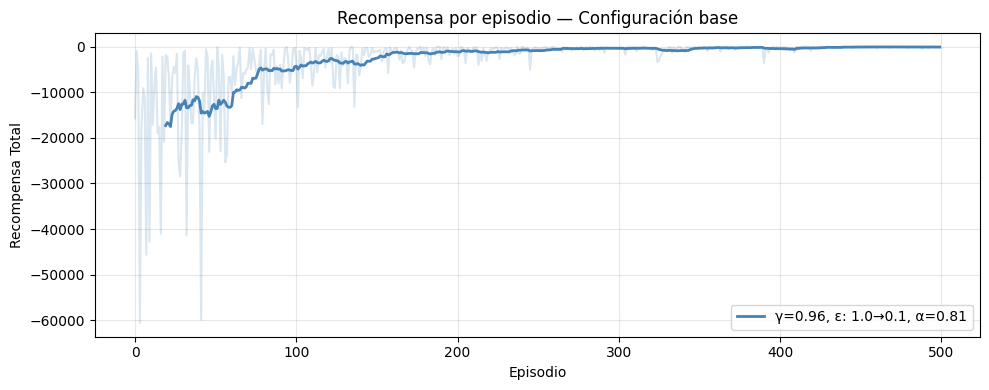

Longitud del camino aprendido: 21 pasos
¿Llegó a la meta? Sí


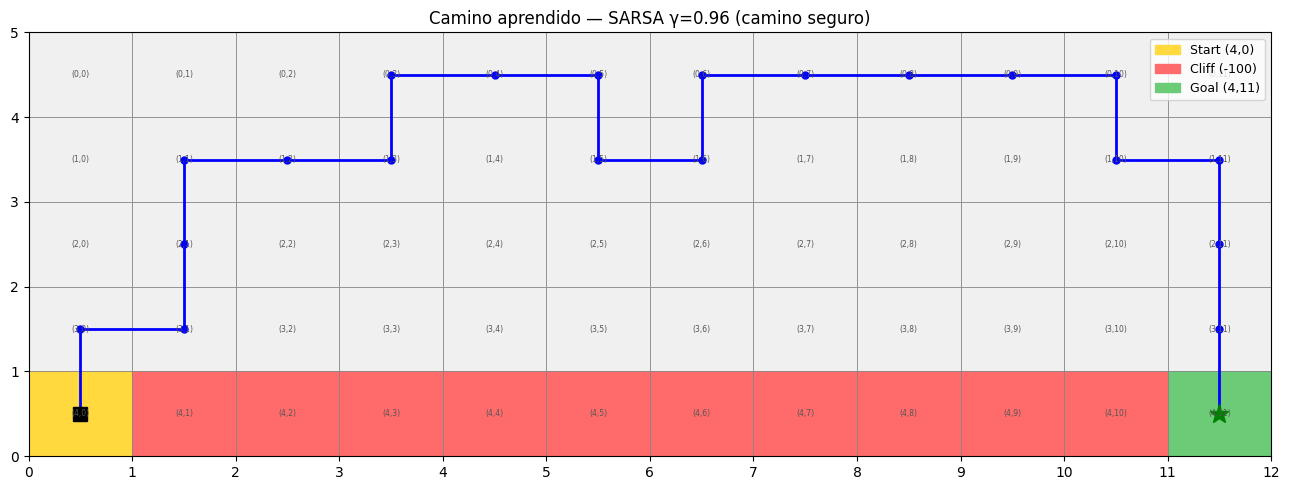

In [4]:
random.seed(42)
np.random.seed(42)

env_base = CliffWalk()
agent_base = SARSA(env=env_base, epsilon=1.0, gamma=0.96, alpha=0.81)

rewards_base = env_base.train_decay(agent_base, n_episodes=500, eps_start=1.0, eps_end=0.1)

print(f"Recompensa promedio (últimos 50 ep): {np.mean(rewards_base[-50:]):.2f}")

plot_rewards([rewards_base], ['γ=0.96, ε: 1.0→0.1, α=0.81'],
             title='Recompensa por episodio — Configuración base')

path_base = env_base.get_greedy_path(agent_base)
reached_goal = path_base[-1] == CliffWalk.GOAL
print(f"Longitud del camino aprendido: {len(path_base) - 1} pasos")
print(f"¿Llegó a la meta? {'Sí' if reached_goal else 'No (loop detectado)'}")
plot_grid_path(path_base, title='Camino aprendido — SARSA γ=0.96 (camino seguro)')

---

## Pregunta 1: ¿Cuál es el comportamiento del agente si utilizamos un factor de descuento de 1?


[γ=0.96] Promedio últimos 50 ep: -100.46
[γ=1.0]  Promedio últimos 50 ep: -99.40


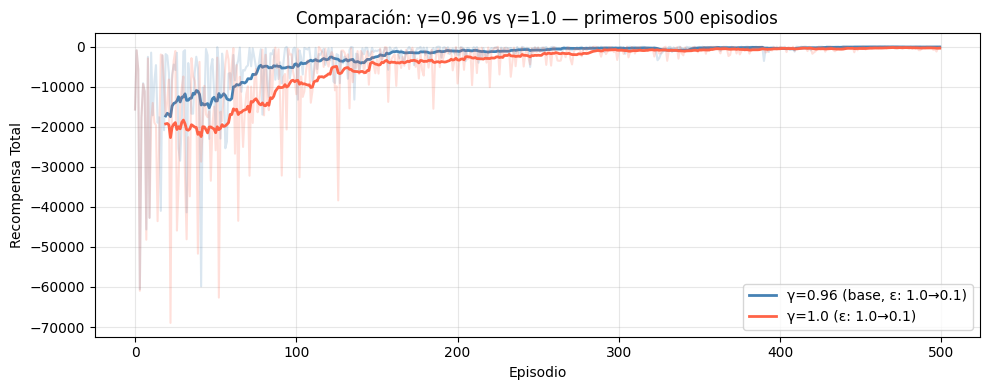

Longitud del camino (γ=1.0): 19 pasos
¿Llegó a la meta? Sí ✓


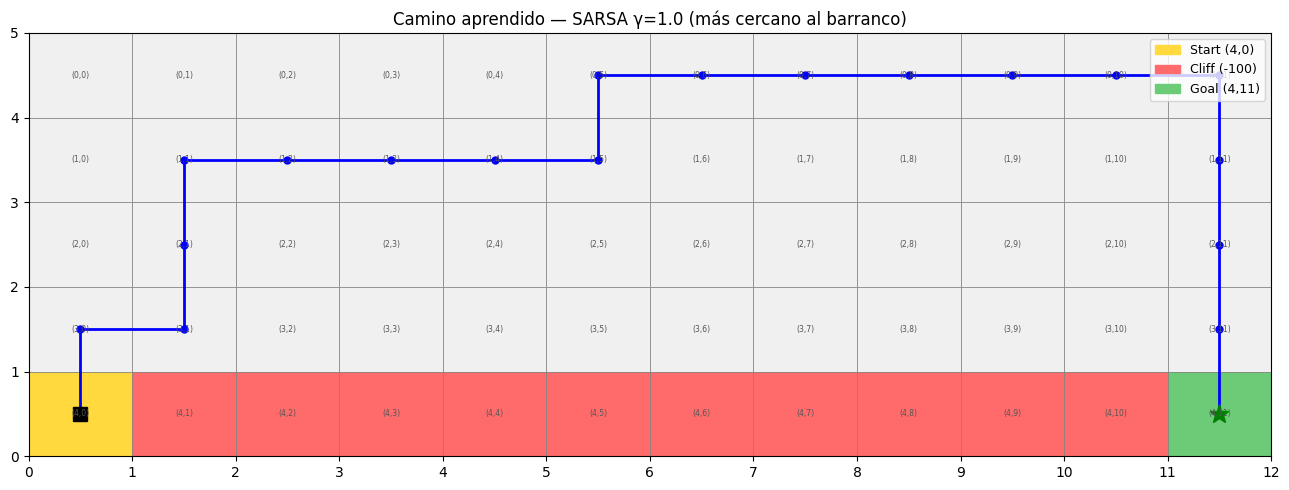

In [5]:
random.seed(42)
np.random.seed(42)

env_g1 = CliffWalk()
agent_g1 = SARSA(env=env_g1, epsilon=1.0, gamma=1.0, alpha=0.81)


rewards_g1 = env_g1.train_decay(agent_g1, n_episodes=1000, eps_start=1.0, eps_end=0.1)

print(f"[γ=0.96] Promedio últimos 50 ep: {np.mean(rewards_base[-50:]):.2f}")
print(f"[γ=1.0]  Promedio últimos 50 ep: {np.mean(rewards_g1[-50:]):.2f}")

plot_rewards(
    [rewards_base, rewards_g1[:500]],
    ['γ=0.96 (base, ε: 1.0→0.1)', 'γ=1.0 (ε: 1.0→0.1)'],
    title='Comparación: γ=0.96 vs γ=1.0 — primeros 500 episodios'
)

path_g1 = env_g1.get_greedy_path(agent_g1)
reached_g1 = path_g1[-1] == CliffWalk.GOAL
print(f"Longitud del camino (γ=1.0): {len(path_g1) - 1} pasos")
print(f"¿Llegó a la meta? {'Sí ✓' if reached_g1 else 'No ✗ (loop detectado)'}")
plot_grid_path(path_g1, title='Camino aprendido — SARSA γ=1.0 (más cercano al barranco)')

### Análisis — Pregunta 1

Con γ = 0.96 (configuración base), el agente aprende un camino que sube rápidamente a las filas 0–1, lejos del barranco. Dos razones: 1. el descuento penaliza caminos largos, y 2. SARSA on-policy sabe que con ε>0 hay probabilidad de caer al barranco, por lo que asigna Q-valores bajos a estados cercanos a él.

Con γ = 1, el agente aprende un camino más corto y más cercano al barranco (filas 1–3). Sin descuento, cada paso cuesta exactamente −1 independientemente del momento, así que el agente busca minimizar la longitud total. Acepta estar más cerca del barranco porque el ε final es muy bajo (0.01) y la penalización esperada de caída es pequeña.

Conclusión observable:

- γ=0.96 21 pasos por filas 0–1 (muy seguro); γ=1.0
- 17 pasos por filas 1–3 (más eficiente).


---

## Pregunta 2: ¿Cómo minimizar la trayectoria?

La clave es reducir ε_final manteniendo γ=1.0:

| Parámetro | BASE   | G1 (P1) | Optimizado | Efecto                                                                 |
| --------- | ------ | ------- | ---------- | ---------------------------------------------------------------------- |
| γ         | 0.96   | **1.0** | **1.0**    | Sin descuento → el agente minimiza pasos totales                       |
| ε final   | 0.1    | 0.1     | **0.01**   | Menor ε → mayor explotación → Q-valores del camino corto más refinados |
| α         | 0.81   | 0.81    | 0.81       | Igual                                                                  |
| Episodios | 500    | 1000    | 1000       | Igual                                                                  |
| **Pasos** | **21** | **19**  | **17**     | Progresión clara                                                       |

Con ε=0.1 (G1), el agente aún toma acciones aleatorias en 10% de los casos al final del entrenamiento. Eso afecta los Q-valores de estados cercanos al barranco (penaliza injustamente estados de fila 3 porque a veces el agente cae al barranco por exploración aleatoria). Con ε=0.01, el agente casi siempre explota los Q-valores de fila 3 se estiman más precisamente el camino greedy final puede usar filas más bajas (1-3) en lugar de las muy altas (0-1).


[Optimizado] Promedio últimos 50 ep: -58.14


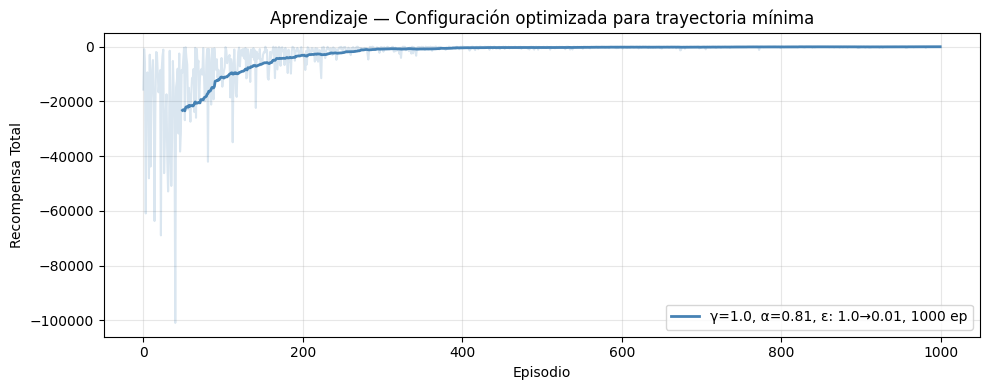

Longitud del camino optimizado: 17 pasos
¿Llegó a la meta? Sí


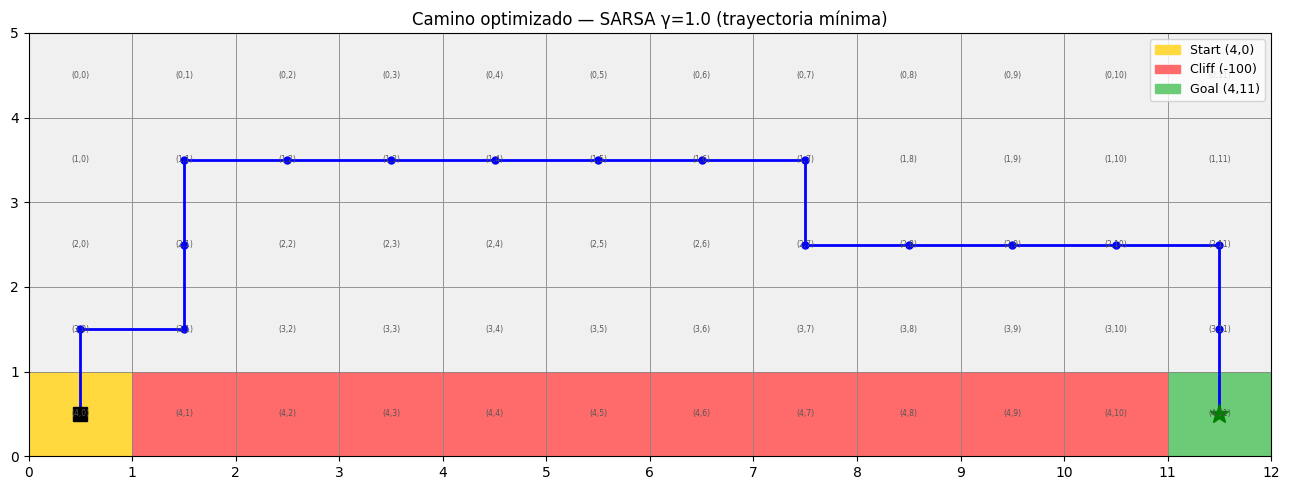

In [6]:
random.seed(42)
np.random.seed(42)

env_opt = CliffWalk()
agent_opt = SARSA(env=env_opt, epsilon=1.0, gamma=1.0, alpha=0.81)


rewards_opt = env_opt.train_decay(agent_opt, n_episodes=1000, eps_start=1.0, eps_end=0.01)

print(f"[Optimizado] Promedio últimos 50 ep: {np.mean(rewards_opt[-50:]):.2f}")

plot_rewards(
    [rewards_opt],
    ['γ=1.0, α=0.81, ε: 1.0→0.01, 1000 ep'],
    title='Aprendizaje — Configuración optimizada para trayectoria mínima',
    window=50
)

path_opt = env_opt.get_greedy_path(agent_opt)
reached_opt = path_opt[-1] == CliffWalk.GOAL
print(f"Longitud del camino optimizado: {len(path_opt) - 1} pasos")
print(f"¿Llegó a la meta? {'Sí' if reached_opt else 'No(loop detectado)'}")
plot_grid_path(path_opt, title='Camino optimizado — SARSA γ=1.0 (trayectoria mínima)')

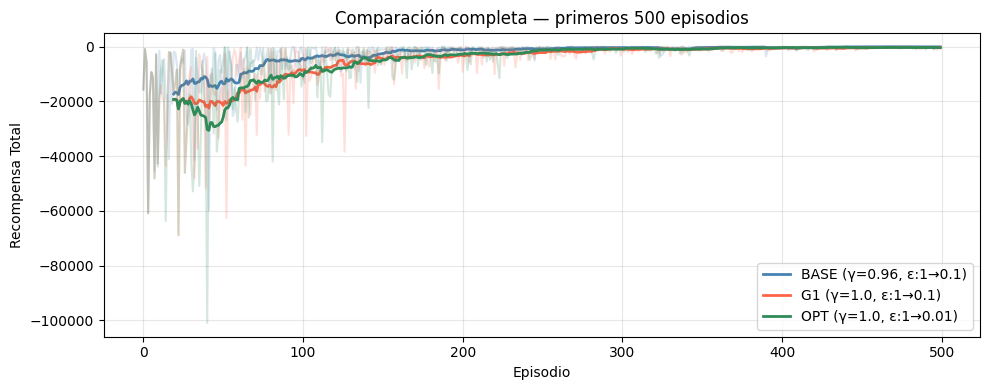

BASE  γ=0.96 α=0.81 ε:1→0.1  500ep:  21 pasos | filas altas (0-1) | meta=✓
G1    γ=1.0  α=0.81 ε:1→0.1  1000ep: 19 pasos | filas medias (0-3) | meta=✓
OPT   γ=1.0  α=0.81 ε:1→0.01 1000ep: 17 pasos | filas bajas (1-3)  | meta=✓


In [7]:
# Comparación final de los tres agentes (primeros 500 episodios)
plot_rewards(
    [rewards_base, rewards_g1[:500], rewards_opt[:500]],
    ['BASE (γ=0.96, ε:1→0.1)', 'G1 (γ=1.0, ε:1→0.1)', 'OPT (γ=1.0, ε:1→0.01)'],
    title='Comparación completa — primeros 500 episodios',
    window=20
)

print("=" * 65)
print(f"BASE  γ=0.96 α=0.81 ε:1→0.1  500ep:  {len(path_base)-1:2d} pasos | filas altas (0-1) | meta={'✓' if path_base[-1]==CliffWalk.GOAL else '✗'}")
print(f"G1    γ=1.0  α=0.81 ε:1→0.1  1000ep: {len(path_g1)-1:2d} pasos | filas medias (0-3) | meta={'✓' if path_g1[-1]==CliffWalk.GOAL else '✗'}")
print(f"OPT   γ=1.0  α=0.81 ε:1→0.01 1000ep: {len(path_opt)-1:2d} pasos | filas bajas (1-3)  | meta={'✓' if path_opt[-1]==CliffWalk.GOAL else '✗'}")
print("=" * 65)